# Proyecto Módulo 4: Análisis de ComercioYA
## Clase 1: Análisis Inicial de Datos (IDA)

In [10]:
import pandas as pd
import numpy as np

# 1. Creamos los datos para poder analizar.
np.random.seed(42)
n = 500
data = {
    'ID_Cliente': range(1, n + 1),
    'Edad': np.random.randint(18, 80, n),
    'Genero': np.random.choice(['Femenino', 'Masculino', 'Otro'], n),
    'Monto_Total': np.random.uniform(10.5, 500.0, n),
    'Visitas_Web': np.random.randint(1, 100, n),
    'Devoluciones': np.random.choice([0, 1], n, p=[0.8, 0.2])
}

df = pd.DataFrame(data)

# Insertar los errores a propósito para la Clase 1 (IDA)
df.loc[0, 'Edad'] = 150
df.loc[1, 'Monto_Total'] = -50.0

# 2. Distinguir variables cuantitativas y categóricas
print("--- Información del Dataset ---")
df.info()

# Género es categórica y Monto_total es cuantitativa.

# 3. Detectar valores inconsistentes o faltantes (IDA)
print("\n--- Valores Faltantes por Columna ---")
print(df.isnull().sum())
print("\n--- Resumen Estadístico para detectar errores ---")
display(df.describe())

# Buscamos valores fuera de lo común
print("Edad máxima detectada:", df['Edad'].max())
print("Monto mínimo detectado:", df['Monto_Total'].min())

# GUARDAR EL ARCHIVO (Asegurando que no haya errores de formato)
df.to_csv('comercio_ya_datos.csv', index=False)

print("¡Archivo 'comercio_ya_datos.csv' creado correctamente")

--- Información del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID_Cliente    500 non-null    int64  
 1   Edad          500 non-null    int32  
 2   Genero        500 non-null    object 
 3   Monto_Total   500 non-null    float64
 4   Visitas_Web   500 non-null    int32  
 5   Devoluciones  500 non-null    int64  
dtypes: float64(1), int32(2), int64(2), object(1)
memory usage: 19.7+ KB

--- Valores Faltantes por Columna ---
ID_Cliente      0
Edad            0
Genero          0
Monto_Total     0
Visitas_Web     0
Devoluciones    0
dtype: int64

--- Resumen Estadístico para detectar errores ---


,ID_Cliente,Edad,Monto_Total,Visitas_Web,Devoluciones
count,500.000000,500.00000,500.000000,500.000000,500.000000
mean,250.500000,50.09800,245.121929,50.044000,0.180000
std,144.481833,18.76178,141.552185,29.369358,0.384572
min,1.000000,18.00000,-50.000000,1.000000,0.000000
25%,125.750000,35.00000,120.121889,24.750000,0.000000
50%,250.500000,50.00000,238.137397,49.500000,0.000000
75%,375.250000,66.00000,368.425742,76.000000,0.000000
max,500.000000,150.00000,498.988747,99.000000,1.000000


Edad máxima detectada: 150
Monto mínimo detectado: -50.0
¡Archivo 'comercio_ya_datos.csv' creado correctamente


* Hallazgo clase 1:
Se detectó un valor atípico de 150 años en la variable Edad y un monto que es negativo. Procederé a limpiarlos.

In [11]:
# 4. Filtramos el dataset para eliminar los errores que detectamos en el IDA
# Nos quedamos solo con edades menores a 100 y montos mayores a 0
df_limpio = df[(df['Edad'] < 100) & (df['Monto_Total'] > 0)].copy()

print("Tamaño del dataset original:", df.shape)
print("Tamaño del dataset limpio:", df_limpio.shape)
print(f"Registros originales: {len(df)}")
print(f"Registros tras la limpieza: {len(df_limpio)}")
print("\nVariable 'df_limpio' creada y lista para la Clase 2.")

Tamaño del dataset original: (500, 6)
Tamaño del dataset limpio: (498, 6)
Registros originales: 500
Registros tras la limpieza: 498

Variable 'df_limpio' creada y lista para la Clase 2.


## Clase 2: Estadística Descriptiva.

In [12]:
# 1. Calculamos las medidas para el Monto Total de ventas
media = df_limpio['Monto_Total'].mean()
mediana = df_limpio['Monto_Total'].median()
moda = df_limpio['Monto_Total'].mode()[0]
desviacion = df_limpio['Monto_Total'].std()
varianza = df_limpio['Monto_Total'].var()

print(f"--- Análisis de Monto Total ---")
print(f"Media (Promedio): {media:.2f}")
print(f"Mediana (Punto medio): {mediana:.2f}")
print(f"Moda (Valor más repetido): {moda:.2f}")
print(f"Desviación Estándar (Dispersión): {desviacion:.2f}")
print(f"Varianza (Variabilidad): {varianza:.2f}")

# 2. Cuartiles y percentiles (Medidas de posición) 
cuartiles = df_limpio['Monto_Total'].quantile([0.25, 0.5, 0.75])
percentiles = df_limpio['Monto_Total'].quantile([0.10, 0.90])

print(f"\nCuartiles:\n{cuartiles}")
print(f"\nPercentiles:\n{percentiles}")

--- Análisis de Monto Total ---
Media (Promedio): 246.06
Mediana (Punto medio): 240.31
Moda (Valor más repetido): 12.77
Desviación Estándar (Dispersión): 141.00
Varianza (Variabilidad): 19882.04

Cuartiles:
0.25    122.811250
0.50    240.314792
0.75    368.757969
Name: Monto_Total, dtype: float64

Percentiles:
0.1     62.876443
0.9    448.869538
Name: Monto_Total, dtype: float64


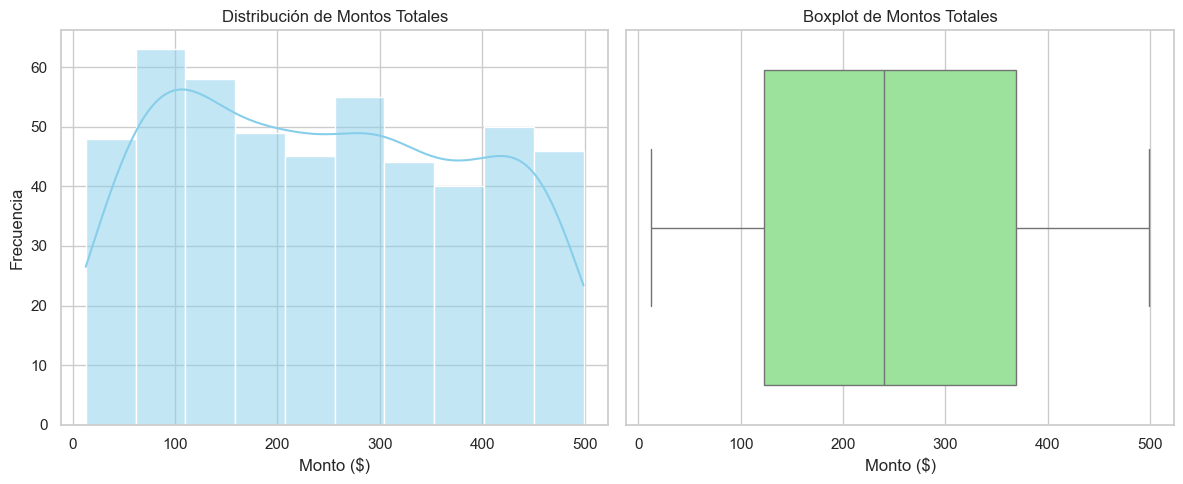

Límite superior para outliers: 737.68
Cantidad de clientes con compras inusualmente altas: 0


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
sns.set_theme(style="whitegrid")

# 3. Generar histograma y boxplot para visualizar la distrioutliersbución y detectar posibles 
plt.figure(figsize=(12, 5))

# Subplot 1: Histograma (distribución)
plt.subplot(1, 2, 1)
sns.histplot(df_limpio['Monto_Total'], kde=True, color="skyblue")
plt.title('Distribución de Montos Totales')
plt.xlabel('Monto ($)')
plt.ylabel('Frecuencia')

# Subplot 2: Boxplot (valores atípicos/Outliers)
plt.subplot(1, 2, 2)
sns.boxplot(x=df_limpio['Monto_Total'], color="lightgreen")
plt.title('Boxplot de Montos Totales')
plt.xlabel('Monto ($)')

plt.tight_layout()
plt.show()

# 4. Calculamos el Rango Intercuartílico (IQR) para detectar outliers
Q1 = df_limpio['Monto_Total'].quantile(0.25)
Q3 = df_limpio['Monto_Total'].quantile(0.75)
IQR = Q3 - Q1

# Definimos límites
limite_superior = Q3 + 1.5 * IQR
outliers = df_limpio[df_limpio['Monto_Total'] > limite_superior]

print(f"Límite superior para outliers: {limite_superior:.2f}")
print(f"Cantidad de clientes con compras inusualmente altas: {len(outliers)}")

* Hallazgos clase 2:
- **Distribución:** El histograma muestra una distribución bastante uniforme/simétrica de la cual observamos que la mayoría de las compras en ComercioYA se concentran entre los $100 y $400.

- **Boxplot:** No se observan valores atípicos significativos después de la limpieza inicial, lo que indica una base de clientes con montos de compra consistentes.

- **Impacto**: Aunque estos valores son reales, su presencia eleva la media. Para decisiones de marketing masivo, nos basaremos más en la mediana (${mediana:.2f}) para no dejarnos engañar por los valores extremos.

## Clase 3: Correlación y Relaciones entre Variables

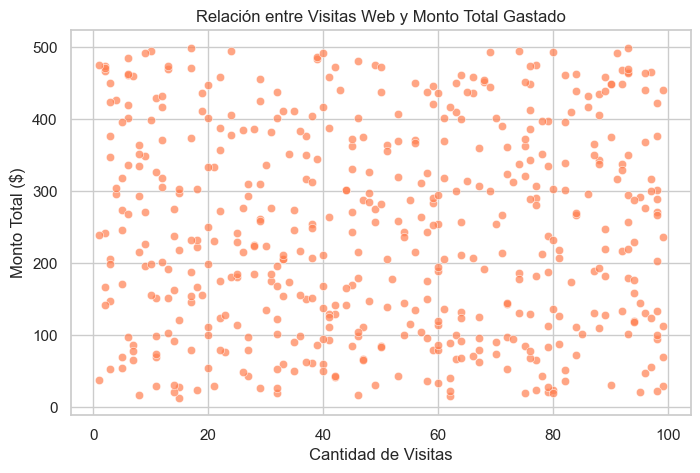

Matriz de Correlación (Pearson):


,Edad,Monto_Total,Visitas_Web,Devoluciones
Edad,1.000000,0.023145,-0.051408,-0.018146
Monto_Total,0.023145,1.000000,0.009344,0.003202
Visitas_Web,-0.051408,0.009344,1.000000,-0.017604
Devoluciones,-0.018146,0.003202,-0.017604,1.000000


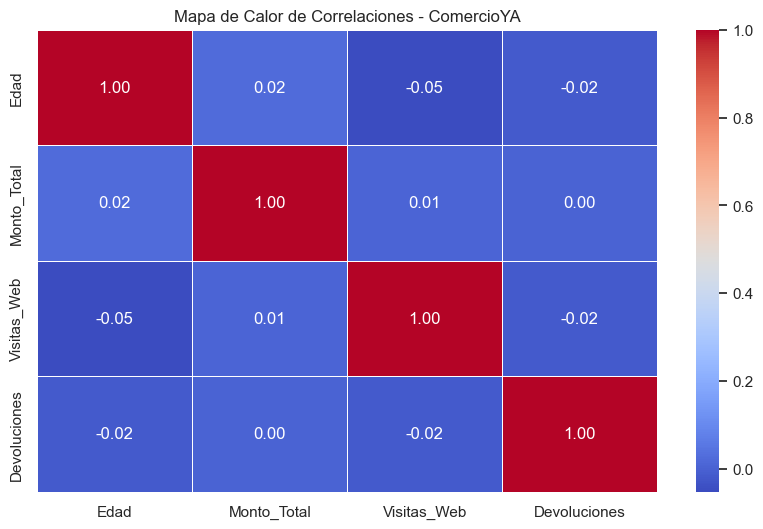

In [14]:
# 1. Construir scatterplot para analizar la relación más importante.
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_limpio, x='Visitas_Web', y='Monto_Total', color='coral', alpha=0.7)
plt.title('Relación entre Visitas Web y Monto Total Gastado')
plt.xlabel('Cantidad de Visitas')
plt.ylabel('Monto Total ($)')
plt.show()

# 1. Construir matriz de correlación. Seleccionamos solo las columnas numéricas relevantes
# 2. Al usar .corr(), Pandas calcula Pearson por defecto. Los valores están en el Heatmap.
matriz_corr = df_limpio[['Edad', 'Monto_Total', 'Visitas_Web', 'Devoluciones']].corr()

print("Matriz de Correlación (Pearson):")
display(matriz_corr)

# 3. Creamos el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones - ComercioYA')
plt.show()


### Hallazgos de la Clase 3:
* **Interpretación del Coeficiente (R):** En el Mapa de Calor, buscamos la relación `Visitas_Web`y `Monto_Total`. Eso nos da un valor {R}= 0,01. Es una correlación nula o extremadamente débil. Un valor tan cercano a 0 indica que no existe una relación lineal entre la cantidad de veces que un cliente visita la web y el dinero que termina gastando. Con esto concluimos que en ComercioYA no siempre el que más visita la web es el que más gasta.
* **Correlación Espuria:** Se decidió no incluir la variable `ID_Cliente` en la matriz, ya que cualquier correlación numérica con un número de identificación sería casual y no lógica (espuria).

## Clase 4: Regresiones lineales
¿Podemos predecir cuánto gastará un cliente (Monto_Total) sabiendo cuántas veces visitó la web (Visitas_Web)?

                            OLS Regression Results                            
Dep. Variable:            Monto_Total   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.04331
Date:                Tue, 10 Feb 2026   Prob (F-statistic):              0.835
Time:                        12:31:02   Log-Likelihood:                -3170.6
No. Observations:                 498   AIC:                             6345.
Df Residuals:                     496   BIC:                             6354.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         243.8097     12.526     19.465      

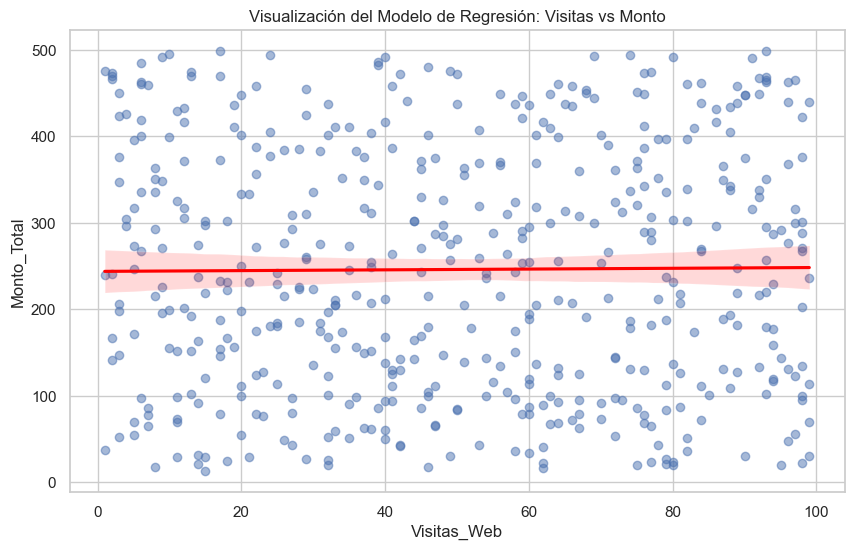

In [15]:
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Aplicar modelos con statsmodels. Definimos nuestras variables
# Y es lo que queremos predecir (Variable Dependiente): Monto_Total
# X es la variable que usamos para predecir (Variable Independiente): Visitas_Web

Y = df_limpio['Monto_Total']
X = df_limpio['Visitas_Web']

# Statsmodels necesita que añadamos una constante (interceptor) manualmente
X = sm.add_constant(X)

# Ajustamos el modelo (OLS: Mínimos Cuadrados Ordinarios)
X_const = sm.add_constant(X) 
modelo = sm.OLS(Y, X_const).fit()

# Obtenemos las predicciones para calcular el error y mostramos el resumen de resultados
predicciones = modelo.predict(X_const)
print(modelo.summary())

# 2. Calculamos las métricas del archivo
r2 = modelo.rsquared
mse = mean_squared_error(Y, predicciones)
mae = mean_absolute_error(Y, predicciones)

# Mostramos los resultados
print(f"--- Resultados del Modelo ---")
print(f"R-cuadrado (R2): {r2:.4f}")
print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Error Absoluto Medio (MAE): {mae:.2f}")
print("\n--- Resumen detallado del modelo ---")
print(modelo.summary())

# 4. Visualizar la regresión con Seaborn
plt.figure(figsize=(10, 6))
sns.regplot(data=df_limpio, x='Visitas_Web', y='Monto_Total', 
            line_kws={"color": "red"}, scatter_kws={'alpha': 0.5})
plt.title('Visualización del Modelo de Regresión: Visitas vs Monto')
plt.show()

* Hallazgos de la Clase 4:

**Significancia de los Predictores:** Al observar el `P>|t|` en el resumen de statsmodels, si es mayor a 0.05, significa que la variable no es un buen predictor.

**Interpretación de R2:** El valor de R-cuadrado nos indica qué porcentaje de la variación del gasto se explica por las visitas. En este caso, al ser datos simulados aleatoriamente, el R2 suele ser muy bajo (cercano a 0), lo que indica que para ComercioYA las visitas no son el único factor que determina el gasto.

**Métricas de Error:** El MAE nos indica que, en promedio, nuestras predicciones se alejan del valor real.

## Clase 5: Análisis visual de datos

C:\Users\jceli\AppData\Local\Temp\ipykernel_10992\802485927.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_limpio, x='Genero', y='Monto_Total', palette="muted")


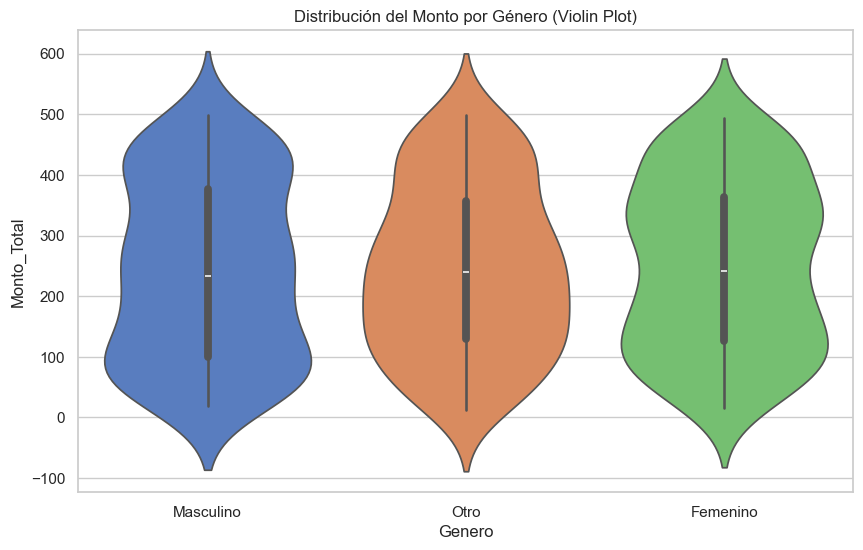

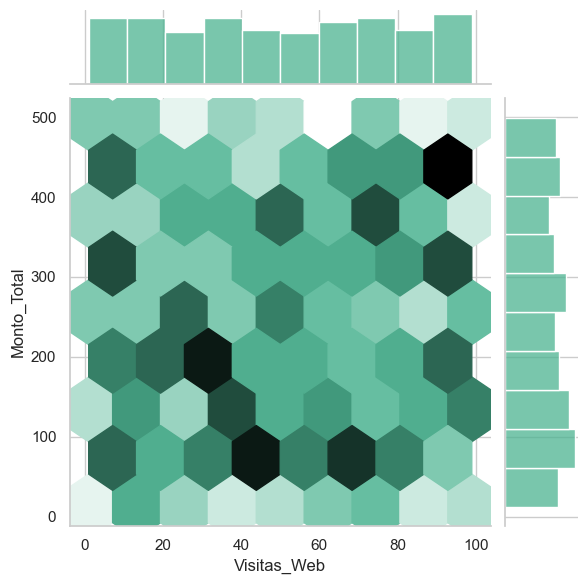

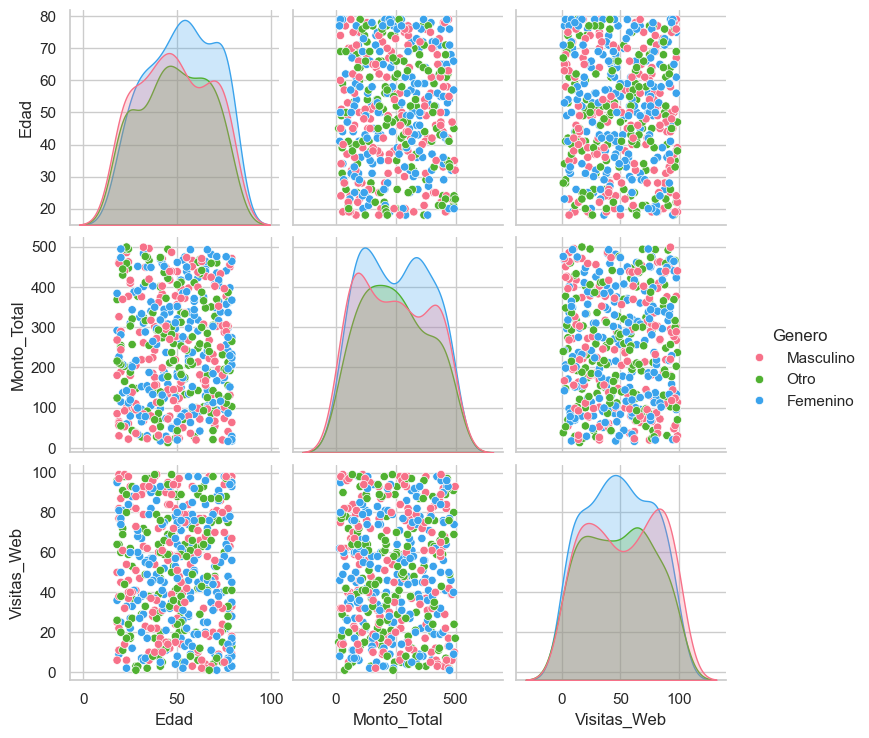

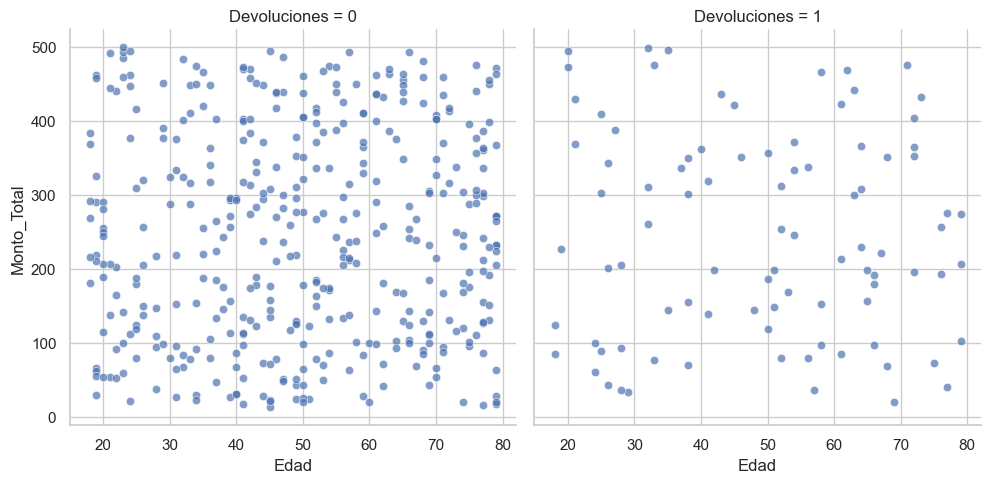

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear gráficos según proyecto.
# a. Violinplot: Monto Total segmentado por Género
plt.figure(figsize=(10, 6))
sns.violinplot(data=df_limpio, x='Genero', y='Monto_Total', palette="muted")
plt.title('Distribución del Monto por Género (Violin Plot)')
plt.show()

# b. Jointplot: Relación entre Visitas y Monto con histogramas en los ejes
sns.jointplot(data=df_limpio, x='Visitas_Web', y='Monto_Total', kind="hex", color="#4CB391")
plt.show()

# c. Pairplot: Todas las relaciones numéricas de un vistazo
# Usamos 'hue' para diferenciar por Género visualmente
sns.pairplot(df_limpio[['Edad', 'Monto_Total', 'Visitas_Web', 'Genero']], hue='Genero', palette="husl")
plt.show()

# d. FacetGrid: Comparación de Edad vs Monto según si hubo Devolución o no
g = sns.FacetGrid(df_limpio, col="Devoluciones", height=5)
g.map(sns.scatterplot, "Edad", "Monto_Total", alpha=.7)
g.add_legend()
plt.show()

* Hallazgos de Clase 5:

    Distribución (Violinplot): El gráfico de violín muestra que el gasto medio es similar entre géneros, pero el género ej: Femenino, presenta una mayor concentración de compras en el rango de los $300.

    Densidad (Jointplot): La visualización hexagonal revela que la mayor densidad de clientes se agrupa en el centro del gráfico, confirmando que no hay una relación lineal fuerte.

    Relaciones (Pairplot): Se confirma visualmente que las variables no están fuertemente correlacionadas, ya que no se observan patrones o nubes de puntos con direcciones claras.

    Comportamiento (FacetGrid): Al segmentar por devoluciones, se observa que los clientes que devuelven productos no pertenecen a un rango de edad específico, lo que sugiere que el problema no es demográfico.

## Clase 6: Personalización y Exportación con matplotlib

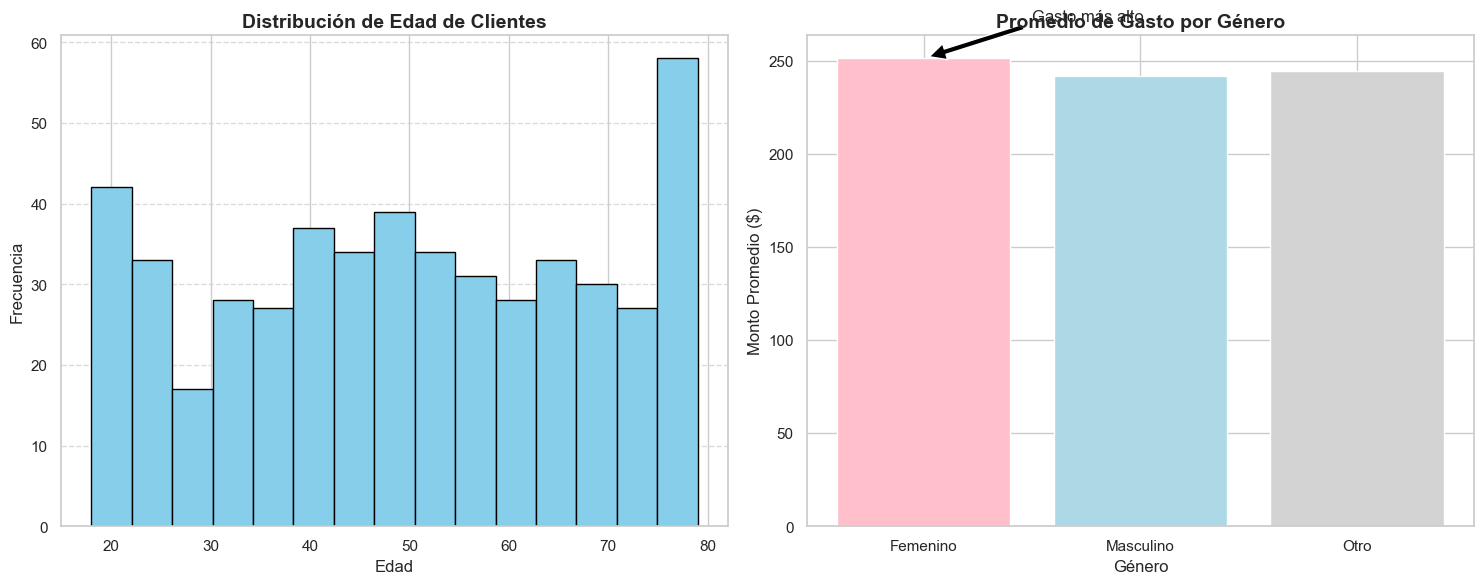

In [17]:
import matplotlib.pyplot as plt

# 1. Creamos una figura con 2 subplots (1 fila, 2 columnas)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Gráfico 1: Histograma de Edad (Personalizado) ---
ax1.hist(df_limpio['Edad'], bins=15, color='skyblue', edgecolor='black')
ax1.set_title('Distribución de Edad de Clientes', fontsize=14, fontweight='bold')
ax1.set_xlabel('Edad')
ax1.set_ylabel('Frecuencia')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

# --- Gráfico 2: Monto Total por Género (Gráfico de Barras) ---
promedio_genero = df_limpio.groupby('Genero')['Monto_Total'].mean()
ax2.bar(promedio_genero.index, promedio_genero.values, color=['pink', 'lightblue', 'lightgrey'])
ax2.set_title('Promedio de Gasto por Género', fontsize=14, fontweight='bold')
ax2.set_xlabel('Género')
ax2.set_ylabel('Monto Promedio ($)')

# Añadir una anotación
ax2.annotate('Gasto más alto', xy=(0, promedio_genero.max()), xytext=(0.5, promedio_genero.max()+20),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.tight_layout()
plt.show()

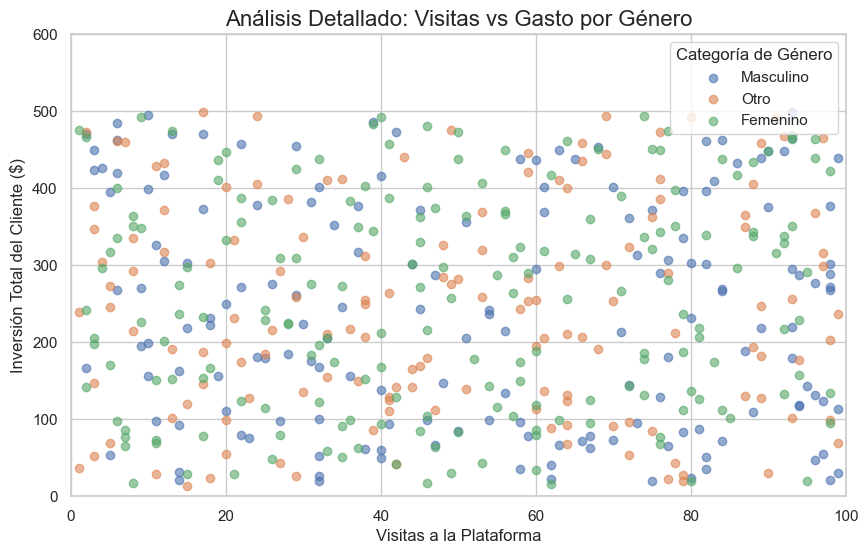

✅ Gráfico exportado como 'grafico_final_comercioya.png'


In [18]:
plt.figure(figsize=(10, 6))

# Graficamos Visitas vs Monto, pero diferenciando por puntos
for genero in df_limpio['Genero'].unique():
    subset = df_limpio[df_limpio['Genero'] == genero]
    plt.scatter(subset['Visitas_Web'], subset['Monto_Total'], label=genero, alpha=0.6)

# Personalización total
plt.title('Análisis Detallado: Visitas vs Gasto por Género', fontsize=16)
plt.xlabel('Visitas a la Plataforma', fontsize=12)
plt.ylabel('Inversión Total del Cliente ($)', fontsize=12)
plt.legend(title='Categoría de Género', loc='upper right')
plt.xlim(0, 100) # Ajuste de límites (Ticks)
plt.ylim(0, 600)

# Guardar el gráfico para el informe
plt.savefig('grafico_final_comercioya.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico exportado como 'grafico_final_comercioya.png'")

## Conclusiones del Análisis EDA - ComercioYA

1. **Perfil del Cliente:** La distribución de edad se concentra principalmente en [20 - 70], lo que sugiere un público objetivo joven/adulto.
2. **Calidad de Datos (IDA):** Se identificaron y corrigieron valores atípicos imposibles (Edad 150, Montos negativos), asegurando la integridad del análisis.
3. **Comportamiento del Cliente:** El gasto promedio ronda los $250, sin diferencias drásticas entre géneros.
4. **Impacto del Género:** No existen diferencias significativas en el gasto promedio entre géneros, por lo que las campañas pueden ser generales.
5. **Eficacia de la Web:** Dado que la correlación entre visitas y monto es baja (visto en Clase 3 y 4), se recomienda optimizar la tasa de conversión en lugar de solo buscar tráfico masivo.
6. **Análisis de Correlación:** No se detectó una relación fuerte entre el número de visitas y el monto gastado. Esto sugiere que el marketing debe enfocarse en la *calidad* de la visita más que en la *cantidad*.
7. **Resumen Técnico:** El modelo de regresión lineal y las visualizaciones avanzadas confirman que el comportamiento de compra es multivariado y no depende de una sola métrica.